# Vocoder vs. model grain test

Isolate **where the grain comes from** by vocoding the same mels two different ways.
For one held-out (validation) clip we take:

- the **ground-truth mel** (`x1`, the target), and
- the **model output mel** (Arioso EMA checkpoint, integrated from the prior),

and render each of them through **two independent vocoders**:

1. **BigVGAN-v2** — the project's neural vocoder (the one used everywhere else).
2. **Griffin-Lim** — a classical, phase-reconstruction vocoder with *no learned weights*.

That gives four clips. The logic:

- **GT mel -> BigVGAN vs. GT mel -> Griffin-Lim** isolates the *vocoder*: both get the exact
  same clean target mel. If BigVGAN sounds grainy where Griffin-Lim doesn't (or vice-versa),
  the grain is a property of that vocoder, not the mel.
- **output mel -> {both}** vs. **GT mel -> {both}** isolates the *model*: if grain rides on the
  output mel through *both* vocoders but is absent from the GT mel through *both*, the model's
  mel is what's grainy.

> Griffin-Lim inverts the *same* mel contract as BigVGAN (log-magnitude, slaney-norm librosa
> filterbank, `n_fft=2048`, `hop=512`, `win=2048`). It has no learned prior, so it is a rougher
> baseline overall — the point is not that it sounds better, but that its grain is *independent*
> of BigVGAN's.

> Run from the **project root** so the `Arioso` / `DataSynthesizer` / `common` packages import.

In [1]:
%matplotlib inline
import os
import random
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt
from IPython.display import display, Audio, Markdown

from common.config import SR, HOP_SIZE, N_FFT, WIN_SIZE, N_MELS, FMIN, FMAX
from common.vocoder import load_vocoder, vocode
from DataSynthesizer.config import DEFAULT_OUT

from Arioso.config import CKPT_DIR, PRIOR_MEL_DIR, AriosoConfig
from Arioso.model import AriosoModel
from Arioso.splits import make_split
from Arioso.clips import enumerate_clips
from Arioso.infer import generate_mel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = DEFAULT_OUT                       # 'data' — the dataset root
CKPT = os.path.join(CKPT_DIR, "checkpoint_step5000.pt")   # the final checkpoint
WEIGHTS = "ema"                             # inference uses the EMA weights
SEED = 0                                    # fixed so the clip draw is reproducible
GL_ITERS = 60                              # Griffin-Lim phase-recovery iterations

cfg = AriosoConfig()
print(f"device={DEVICE}  ckpt={CKPT}")

device=cuda  ckpt=Arioso/models\checkpoint_step5000.pt


## Load the model, the BigVGAN vocoder, and define Griffin-Lim

BigVGAN is loaded on the PyTorch-native path (`use_cuda_kernel=False`) — the fused kernel can't
build on this machine and the native path still runs on the GPU.

The mel stored by the pipeline is **log-magnitude** (`log(clamp(mel_basis @ |STFT|, 1e-5))`).
Griffin-Lim therefore first undoes the log (`exp`), then `librosa.feature.inverse.mel_to_audio`
inverts the mel filterbank (NNLS) and recovers phase iteratively. Every STFT/mel parameter is
pulled from `common.config` so it matches the BigVGAN contract; `power=1.0` because the mel is a
**magnitude** (not power) spectrogram. The one unavoidable difference from BigVGAN's extractor is
framing: librosa uses `center=True`, BigVGAN a manual reflect-pad — a sub-frame shift that is
irrelevant to a grain A/B.

In [ ]:
# Load the checkpoint FIRST, then build the model from ITS embedded config (cfg_from_dict):
# pre-conditioning checkpoints reconstruct the exact old architecture; conditioned ones add cond.
from Arioso.config import cfg_from_dict

ckpt = torch.load(CKPT, map_location=DEVICE)
cfg = cfg_from_dict(ckpt.get("cfg") or {})
model = AriosoModel(cfg).to(DEVICE)
model.load_state_dict(ckpt[WEIGHTS])
model.eval()
print(f"loaded step {ckpt.get('step', '?')}  |  {model.num_params() / 1e6:.1f}M params  |  weights='{WEIGHTS}'")

if DEVICE == "cpu":
    import warnings
    warnings.warn("DEVICE is 'cpu' — CUDA was not available; BigVGAN will run on CPU (slow).")

# The frozen BigVGAN-v2 vocoder (mel -> waveform). Native path (fused kernel can't build here).
voc = load_vocoder(device=DEVICE, use_cuda_kernel=False)

# fmax=None in the config means Nyquist; librosa needs the concrete value.
_FMAX = FMAX if FMAX is not None else SR / 2.0


def griffin_lim_vocode(log_mel, n_iter=GL_ITERS):
    """Invert a [128, T] log-magnitude mel (the BigVGAN contract) to a waveform via Griffin-Lim.

    No learned weights — an independent vocoder baseline. Undoes the log compression, inverts the
    (slaney-norm) mel filterbank with NNLS, then recovers phase iteratively.
    """
    mel_mag = np.exp(np.asarray(log_mel, dtype=np.float64))     # undo log -> linear magnitude
    wav = librosa.feature.inverse.mel_to_audio(
        mel_mag,
        sr=SR, n_fft=N_FFT, hop_length=HOP_SIZE, win_length=WIN_SIZE,
        window="hann", center=True, power=1.0, n_iter=n_iter,
        fmin=FMIN, fmax=_FMAX,
    )
    return wav.astype(np.float32)


def norm(wav, peak=0.95):
    """Peak-normalize for fair listening (Griffin-Lim and BigVGAN levels differ)."""
    m = np.max(np.abs(wav))
    return (wav / m * peak).astype(np.float32) if m > 0 else wav.astype(np.float32)

## Pick one validation clip

Randomly select one held-out **recording** and one random clip from it. `SEED` is fixed above so
the draw is reproducible; change it to audition a different clip.

In [3]:
rng = random.Random(SEED)

split = make_split(OUT_DIR, cfg)
val_clips = enumerate_clips(OUT_DIR, split["val"], cfg)
print(f"val recordings: {len(split['val'])}   val clips: {len(val_clips)}")

by_recording = {}
for c in val_clips:
    by_recording.setdefault(c.basename, []).append(c)

basename = rng.choice(sorted(by_recording))
clip = rng.choice(by_recording[basename])
dur = (clip.end - clip.start) / cfg.sr * cfg.hop
print(f"chosen: {clip.basename}  frames {clip.start}:{clip.end}  (~{dur:.1f}s)")

val recordings: 74   val clips: 56029
chosen: Wohlfahrt_Op45-39_BernardChevalier_ztj_dBul8fU-0000-0115  frames 9190:9621  (~5.0s)


## Load mels and run the model

Load the prior mel (`x0`, model input) and GT mel (`x1`, target), then Euler-integrate the
velocity field from `x0` to get the output mel.

In [4]:
prior_dir = os.path.join(OUT_DIR, PRIOR_MEL_DIR)
target_dir = os.path.join(OUT_DIR, "target_mel")

x0 = np.ascontiguousarray(
    np.load(os.path.join(prior_dir, clip.basename + ".npy"), mmap_mode="r")[:, clip.start:clip.end],
    dtype=np.float32)
x1 = np.ascontiguousarray(
    np.load(os.path.join(target_dir, clip.basename + ".npy"), mmap_mode="r")[:, clip.start:clip.end],
    dtype=np.float32)

out_mel = generate_mel(model, x0, cfg, DEVICE)      # Euler-integrated output mel [128, T]
print(f"prior {x0.shape}  gt {x1.shape}  out {out_mel.shape}")

prior (128, 431)  gt (128, 431)  out (128, 431)


## Vocode the GT mel and the output mel through both vocoders

Four renders: `{GT mel, output mel} × {BigVGAN, Griffin-Lim}`. Griffin-Lim is the slower of the
two (iterative), so this cell can take a little while on CPU.

In [5]:
renders = {}

renders["gt_bigvgan"]  = vocode(voc, torch.from_numpy(x1[None]).float())
renders["out_bigvgan"] = vocode(voc, torch.from_numpy(out_mel[None]).float())
print("BigVGAN done")

renders["gt_griffinlim"]  = griffin_lim_vocode(x1)
renders["out_griffinlim"] = griffin_lim_vocode(out_mel)
print("Griffin-Lim done")

for k, w in renders.items():
    print(f"  {k:<16} {len(w)} samples  (~{len(w) / SR:.1f}s)")

BigVGAN done
Griffin-Lim done
  gt_bigvgan       220672 samples  (~5.0s)
  out_bigvgan      220672 samples  (~5.0s)
  gt_griffinlim    220160 samples  (~5.0s)
  out_griffinlim   220160 samples  (~5.0s)


## Listen

Rows = the **mel** (ground-truth vs. model output); columns = the **vocoder** (BigVGAN vs.
Griffin-Lim). All clips are peak-normalized so level differences between the vocoders don't
confound the grain judgement.

- Compare **across a row** (same mel, two vocoders): grain that appears under only one vocoder is
  that vocoder's.
- Compare **down a column** (GT vs. output, same vocoder): grain present on the output but not the
  GT is the model's mel.

In [6]:
layout = [
    ("Ground-truth mel", "gt_bigvgan", "gt_griffinlim"),
    ("Model output mel", "out_bigvgan", "out_griffinlim"),
]

display(Markdown(f"### `{clip.basename}`  frames {clip.start}:{clip.end}"))
for row_name, big_key, gl_key in layout:
    display(Markdown(f"**{row_name}**"))
    print("BigVGAN-v2:")
    display(Audio(norm(renders[big_key]), rate=SR))
    print("Griffin-Lim:")
    display(Audio(norm(renders[gl_key]), rate=SR))

### `Wohlfahrt_Op45-39_BernardChevalier_ztj_dBul8fU-0000-0115`  frames 9190:9621

**Ground-truth mel**

BigVGAN-v2:


Griffin-Lim:


**Model output mel**

BigVGAN-v2:


Griffin-Lim:


## Mel reference

Prior (model input), model output, and GT mel on a shared color scale, plus the delta
(`output - GT`) — for cross-referencing anything you hear against the mel error.

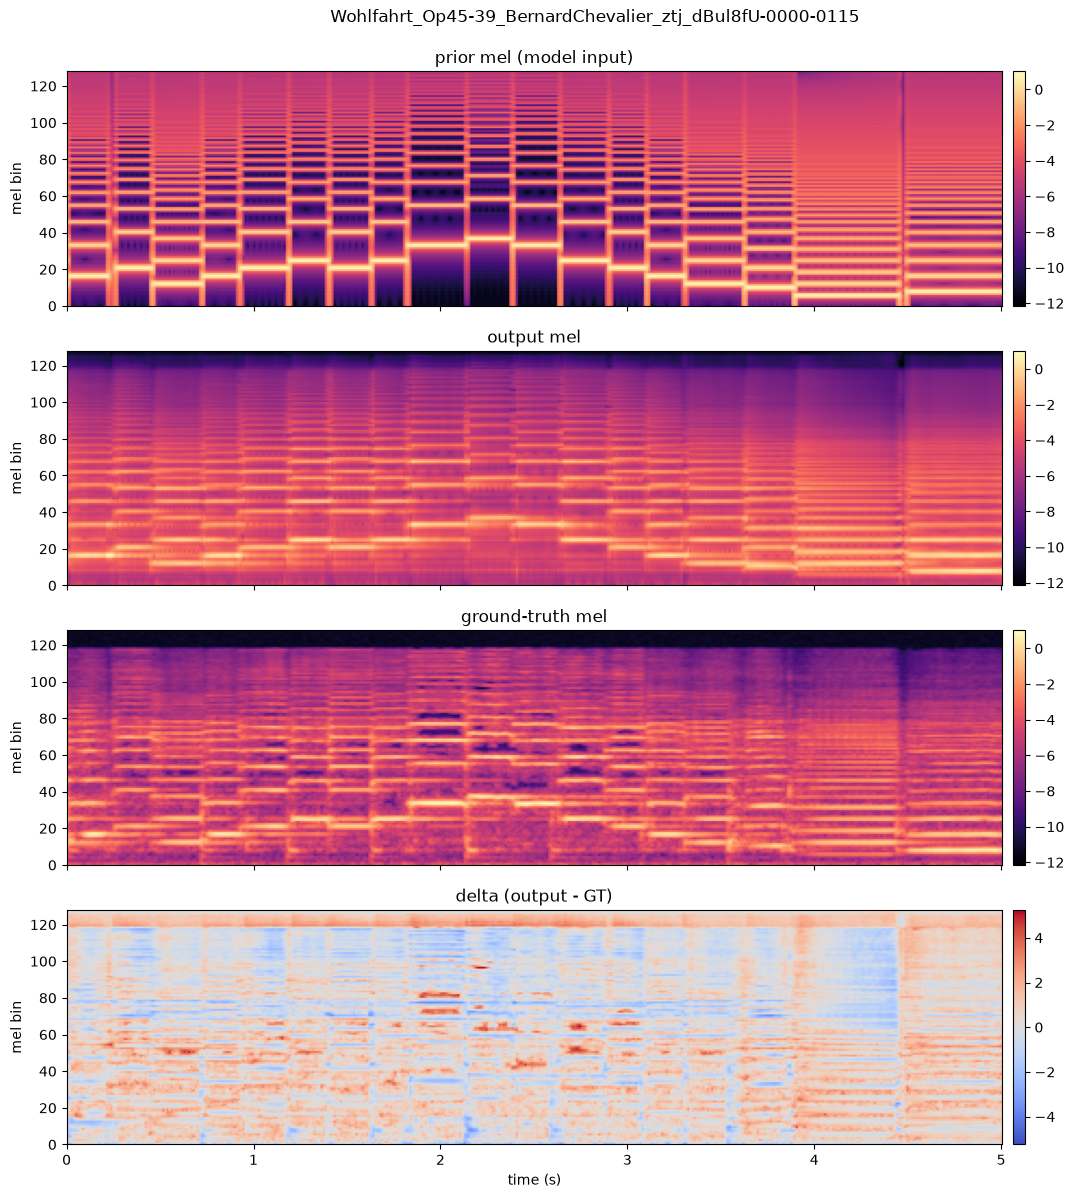

mel MAE 0.8692   mel RMSE 1.0973


In [7]:
def plot_comparison(prior_mel, out_mel, gt_mel, title):
    """Prior, output, GT mels (shared color scale) + the delta (output - GT)."""
    delta = out_mel - gt_mel
    vmin = min(prior_mel.min(), out_mel.min(), gt_mel.min())
    vmax = max(prior_mel.max(), out_mel.max(), gt_mel.max())
    dlim = np.abs(delta).max()
    extent = [0, out_mel.shape[1] / cfg.sr * cfg.hop, 0, cfg.n_mels]

    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
    for ax, data, name, kw in [
        (axes[0], prior_mel, "prior mel (model input)", dict(vmin=vmin, vmax=vmax, cmap="magma")),
        (axes[1], out_mel, "output mel", dict(vmin=vmin, vmax=vmax, cmap="magma")),
        (axes[2], gt_mel, "ground-truth mel", dict(vmin=vmin, vmax=vmax, cmap="magma")),
        (axes[3], delta, "delta (output - GT)", dict(vmin=-dlim, vmax=dlim, cmap="coolwarm")),
    ]:
        im = ax.imshow(data, origin="lower", aspect="auto", extent=extent, **kw)
        ax.set_ylabel("mel bin")
        ax.set_title(name)
        fig.colorbar(im, ax=ax, pad=0.01)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    return fig


fig = plot_comparison(x0, out_mel, x1, clip.basename)
display(fig)
plt.close(fig)
delta = out_mel - x1
print(f"mel MAE {np.mean(np.abs(delta)):.4f}   mel RMSE {np.sqrt(np.mean(delta ** 2)):.4f}")

# Grain localization diagnostic (case a vs. case b)

The A/B above says *whether* the grain tracks the mel or the vocoder. This section **localizes** it
quantitatively across several held-out clips, to decide which fix to invest in — it does **not** fix
anything.

- **Case (a) — mel-domain.** The grain (broadband floor / filled inter-harmonic valleys) is already
  in the model's mel magnitude. Fix lives in the model / loss / prior.
- **Case (b) — vocoder OOD amplification.** The mel is only mildly off, but frozen BigVGAN
  *fabricates* static from a slightly out-of-distribution mel. Fix is vocoder fine-tuning.

**Conventions (per spec).** `m_out` is from the **EMA** weights (`WEIGHTS` above) — this changes the
mel, so it is recorded here. All mel differences are in the model's **log-mel** domain (no mixing
log/linear). **One** front-end everywhere: BigVGAN's own `meldataset.mel_spectrogram` (params
asserted equal to the checkpoint config), reused for the round-trip re-analysis and as the
Griffin-Lim mel basis. All main comparisons run on **sounding frames only**; silent frames are
analyzed **separately** (gate-smear ≠ in-note static). The sounding/silence mask is **score-derived**
from the prior — a MIDI render that is silent between notes.

### Two measurements
1. **Round-trip consistency** `R(m) = |front_end(bigvgan(m)) − m|` on sounding frames. `R(m_gt)` is
   the transparency floor (mel is lossy). `R(m_out) ≈ R(m_gt)` ⇒ BigVGAN renders the model mel
   faithfully ⇒ grain was already in `m_out` (**case a**). `R(m_out) ≫ R(m_gt)` ⇒ BigVGAN's render
   diverges from its own input ⇒ it fabricates energy (**case b**). Plotted per-bin to see *where*
   divergence sits (hypothesis: the upper bins).
2. **Grain metric** = HF (> 4 kHz) spectral flatness on the 2×2 renders. Griffin-Lim is
   magnitude-faithful / phase-broken — it takes the mel magnitude as truth and only invents phase, so
   it cannot fabricate a broadband floor (only choppiness). A large `Δ_gl = grain(out+gl) −
   grain(gt+gl)` therefore means the excess noise is in the mel magnitude (**case a**); `Δ_gl ≈ 0`
   while `Δ_bigvgan` is large means BigVGAN adds it (**case b**). Silent-frame energy is tracked
   separately as the note-gate smear.

In [9]:
import pandas as pd

# --- diagnostic knobs ---------------------------------------------------------------
N_DIAG = 6            # held-out clips for the localization (spec: ~5-10)
DIAG_SEED = 0         # fixed draw
HF_HZ = 4000.0        # HF band for the flatness grain metric (violin harmonics sparse above this)
GATE_DB = -30.0       # score-silent gate: prior-energy frames within GATE_DB of peak are "sounding"

# One front-end everywhere: BigVGAN's OWN meldataset.mel_spectrogram (its params are asserted equal
# to the checkpoint config at load time). Reused for round-trip re-analysis below; the Griffin-Lim
# mel basis (librosa, slaney norm) uses the identical params -> all three share one front-end.
from common.vocoder import mel_spectrogram as _bigvgan_front_end


def front_end_mel(audio):
    """Audio -> [N_MELS, T] log-mel via BigVGAN's own front-end (identical to training)."""
    return _bigvgan_front_end(np.asarray(audio, dtype=np.float32), device=DEVICE)[0].cpu().numpy()


def sounding_mask(prior_mel, gate_db=GATE_DB):
    """Score-derived note-active mask. The prior is a MIDI render (silent between notes), so its
    per-frame linear-magnitude energy is a score-derived gate. Returns [T] bool (True = sounding)."""
    e = np.exp(prior_mel.astype(np.float64)).sum(axis=0)      # linear-magnitude energy per frame
    e_db = 10.0 * np.log10(e / e.max() + 1e-12)
    return e_db > gate_db


_FREQS = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
_HF = _FREQS >= HF_HZ


def hf_flatness(audio):
    """Per-frame spectral flatness (Wiener entropy) in the HF band. Scale-invariant; higher = flatter
    (more broadband static). Violin harmonics are sparse >4 kHz, so static dominates there."""
    S = np.abs(librosa.stft(np.asarray(audio, dtype=np.float32), n_fft=N_FFT,
                            hop_length=HOP_SIZE, win_length=WIN_SIZE, center=True))
    Shf = S[_HF] + 1e-9
    return np.exp(np.mean(np.log(Shf), axis=0)) / np.mean(Shf, axis=0)     # [frames] in (0, 1]


def frame_rms_db(audio):
    """Per-frame RMS in dBFS (for silent-frame energy / note-gate smear)."""
    r = librosa.feature.rms(y=np.asarray(audio, dtype=np.float32),
                            frame_length=N_FFT, hop_length=HOP_SIZE, center=True)[0]
    return 20.0 * np.log10(r + 1e-9)


def _masked_mean(mask, arr):
    """Mean of a per-frame array over masked frames, trimming to the shorter length."""
    T = min(len(mask), len(arr))
    sel = arr[:T][mask[:T]]
    return float(sel.mean()) if sel.size else float("nan")


print(f"m_out weights = '{WEIGHTS}'  |  N_DIAG={N_DIAG}  HF>{HF_HZ:.0f}Hz  gate={GATE_DB}dB")

m_out weights = 'ema'  |  N_DIAG=6  HF>4000Hz  gate=-30.0dB


## Select the diagnostic clip set

`N_DIAG` held-out clips from distinct recordings (same selection scheme as the other notebooks),
fixed `DIAG_SEED` for reproducibility.

In [10]:
drng = random.Random(DIAG_SEED)
diag_names = drng.sample(sorted(by_recording), k=min(N_DIAG, len(by_recording)))
diag_clips = [drng.choice(by_recording[b]) for b in diag_names]
print(f"selected {len(diag_clips)} diagnostic clips:")
for c in diag_clips:
    dur = (c.end - c.start) / cfg.sr * cfg.hop
    print(f"  {c.basename}  frames {c.start}:{c.end}  (~{dur:.1f}s)")

selected 6 diagnostic clips:
  Wohlfahrt_Op45-39_BernardChevalier_ztj_dBul8fU-0000-0115  frames 4969:5828  (~10.0s)
  Wohlfahrt_Op45-39_BrianClement_QU4_IrlYPhs-0000-0110  frames 3956:4813  (~9.9s)
  Kayser_Op20-04_JPRafferty_49hp2uSHLqI-0000-0097  frames 4957:5818  (~10.0s)
  Paganini_Op01-14_AlicanSuner_Yr7oE4WcVCw-0000-0147  frames 5434:6278  (~9.8s)
  Wohlfahrt_Op45-46_ZYZ_eVpAqTyJBQw-0003-0129  frames 4644:5511  (~10.1s)
  Wohlfahrt_Op45-46_BrianClement_QPH5nASSl0A-0000-0103  frames 2638:3495  (~9.9s)


## Run the two measurements

Per clip: integrate the EMA output mel, derive the score sounding mask from the prior, render the
2×2 `{gt, out} × {bigvgan, gl}` grid, then compute the BigVGAN round-trip `R` (Measurement 1) and
the HF-flatness grain metric + silent-frame energy (Measurement 2). Griffin-Lim is iterative, so
this is the slow cell.

In [11]:
prior_dir = os.path.join(OUT_DIR, PRIOR_MEL_DIR)
target_dir = os.path.join(OUT_DIR, "target_mel")


def load_clip_mels(c):
    x0 = np.ascontiguousarray(np.load(os.path.join(prior_dir, c.basename + ".npy"),
                                      mmap_mode="r")[:, c.start:c.end], dtype=np.float32)
    x1 = np.ascontiguousarray(np.load(os.path.join(target_dir, c.basename + ".npy"),
                                      mmap_mode="r")[:, c.start:c.end], dtype=np.float32)
    return x0, x1


diag = []
for i, c in enumerate(diag_clips):
    x0, x1 = load_clip_mels(c)
    m_out = generate_mel(model, x0, cfg, DEVICE)          # EMA output mel [128, T]
    snd = sounding_mask(x0)
    sil = ~snd

    # {gt, out} mel  x  {bigvgan, gl} vocoder  ->  audio
    audio = {
        ("gt", "bigvgan"): vocode(voc, torch.from_numpy(x1[None]).float()),
        ("out", "bigvgan"): vocode(voc, torch.from_numpy(m_out[None]).float()),
        ("gt", "gl"): griffin_lim_vocode(x1),
        ("out", "gl"): griffin_lim_vocode(m_out),
    }

    # --- Measurement 1: BigVGAN round-trip consistency (sounding frames) ------------
    def roundtrip_R(m, a):
        m_hat = front_end_mel(a)
        T = min(m.shape[1], m_hat.shape[1], len(snd))
        Rbin = np.abs(m_hat[:, :T] - m[:, :T])[:, snd[:T]]     # [N_MELS, n_sounding]
        return Rbin.mean(axis=1), float(Rbin.mean())           # per-bin, scalar

    Rbin_gt, R_gt = roundtrip_R(x1, audio[("gt", "bigvgan")])
    Rbin_out, R_out = roundtrip_R(m_out, audio[("out", "bigvgan")])

    # --- Measurement 2: grain (HF flatness, sounding) + silent-frame energy ---------
    grain = {k: _masked_mean(snd, hf_flatness(a)) for k, a in audio.items()}
    silE = {k: _masked_mean(sil, frame_rms_db(a)) for k, a in audio.items()}

    diag.append(dict(basename=c.basename, snd_frac=float(snd.mean()),
                     Rbin_gt=Rbin_gt, Rbin_out=Rbin_out, R_gt=R_gt, R_out=R_out,
                     grain=grain, silE=silE))
    print(f"[{i + 1}/{len(diag_clips)}] {c.basename[:44]:<46} "
          f"snd {snd.mean() * 100:3.0f}%  R_gt {R_gt:.3f}  R_out {R_out:.3f}  "
          f"d_gl {grain[('out', 'gl')] - grain[('gt', 'gl')]:+.3f}")

[1/6] Wohlfahrt_Op45-39_BernardChevalier_ztj_dBul8   snd 100%  R_gt 0.194  R_out 0.171  d_gl +0.121
[2/6] Wohlfahrt_Op45-39_BrianClement_QU4_IrlYPhs-0   snd 100%  R_gt 0.167  R_out 0.170  d_gl -0.091
[3/6] Kayser_Op20-04_JPRafferty_49hp2uSHLqI-0000-0   snd 100%  R_gt 0.150  R_out 0.150  d_gl -0.054
[4/6] Paganini_Op01-14_AlicanSuner_Yr7oE4WcVCw-000   snd 100%  R_gt 0.162  R_out 0.236  d_gl +0.028
[5/6] Wohlfahrt_Op45-46_ZYZ_eVpAqTyJBQw-0003-0129    snd 100%  R_gt 0.184  R_out 0.175  d_gl +0.029
[6/6] Wohlfahrt_Op45-46_BrianClement_QPH5nASSl0A-0   snd 100%  R_gt 0.169  R_out 0.161  d_gl -0.070


## Measurement 1 — per-bin round-trip `R` overlay

`R(m_gt)` (the floor) vs. `R(m_out)`, mean over sounding frames and across clips. Divergence
concentrated in the **upper bins** is the case-(b) signature — BigVGAN extrapolating on the
smoothest part of the model mel.

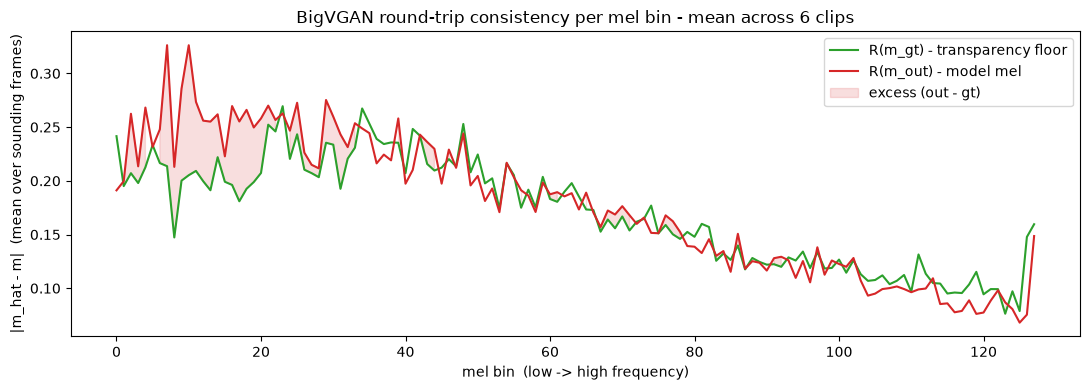

If the red curve lifts off the green mainly in the UPPER bins, BigVGAN is diverging on the smoothest / most-OOD part of the model mel (points to case b).


In [12]:
Rbin_gt_all = np.stack([d["Rbin_gt"] for d in diag]).mean(0)
Rbin_out_all = np.stack([d["Rbin_out"] for d in diag]).mean(0)
bins = np.arange(N_MELS)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(bins, Rbin_gt_all, color="tab:green", label="R(m_gt) - transparency floor")
ax.plot(bins, Rbin_out_all, color="tab:red", label="R(m_out) - model mel")
ax.fill_between(bins, Rbin_gt_all, Rbin_out_all, where=Rbin_out_all > Rbin_gt_all,
                color="tab:red", alpha=0.15, label="excess (out - gt)")
ax.set_xlabel("mel bin  (low -> high frequency)")
ax.set_ylabel("|m_hat - m|  (mean over sounding frames)")
ax.set_title(f"BigVGAN round-trip consistency per mel bin - mean across {len(diag)} clips")
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)
print("If the red curve lifts off the green mainly in the UPPER bins, BigVGAN is diverging on the "
      "smoothest / most-OOD part of the model mel (points to case b).")

## Summary table

Per clip and mean: round-trip `R` (gt, out) and their ratio; the HF grain metric for all four
renders with `d_bigvgan` / `d_gl`; and silent-frame energy (gt, out) through BigVGAN. `d_gl` is the
key case-(a) signal; `R_out/R_gt` the key case-(b) signal.

In [13]:
rows = []
for d in diag:
    g, s = d["grain"], d["silE"]
    rows.append({
        "clip": d["basename"][:32],
        "snd%": round(d["snd_frac"] * 100),
        "R_gt": d["R_gt"], "R_out": d["R_out"], "R_out/R_gt": d["R_out"] / d["R_gt"],
        "grain_gt_big": g[("gt", "bigvgan")], "grain_out_big": g[("out", "bigvgan")],
        "grain_gt_gl": g[("gt", "gl")], "grain_out_gl": g[("out", "gl")],
        "d_bigvgan": g[("out", "bigvgan")] - g[("gt", "bigvgan")],
        "d_gl": g[("out", "gl")] - g[("gt", "gl")],
        "silE_gt_big": s[("gt", "bigvgan")], "silE_out_big": s[("out", "bigvgan")],
    })

df = pd.DataFrame(rows)
mean = df.drop(columns="clip").mean(numeric_only=True)
mean["clip"] = "- MEAN -"
df_disp = pd.concat([df, pd.DataFrame([mean])[df.columns]], ignore_index=True)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
display(df_disp)

,clip,snd%,R_gt,R_out,R_out/R_gt,grain_gt_big,grain_out_big,grain_gt_gl,grain_out_gl,d_bigvgan,d_gl,silE_gt_big,silE_out_big
0,Wohlfahrt_Op45-39_BernardChevali,100.000,0.194,0.171,0.882,0.095,0.194,0.102,0.223,0.099,0.121,NaN,NaN
1,Wohlfahrt_Op45-39_BrianClement_Q,100.000,0.167,0.170,1.017,0.307,0.190,0.312,0.221,-0.117,-0.091,NaN,NaN
2,Kayser_Op20-04_JPRafferty_49hp2u,100.000,0.150,0.150,0.999,0.249,0.192,0.279,0.224,-0.058,-0.054,NaN,NaN
3,Paganini_Op01-14_AlicanSuner_Yr7,100.000,0.162,0.236,1.461,0.191,0.218,0.203,0.231,0.027,0.028,NaN,NaN
4,Wohlfahrt_Op45-46_ZYZ_eVpAqTyJBQ,100.000,0.184,0.175,0.950,0.205,0.218,0.222,0.251,0.014,0.029,NaN,NaN
5,Wohlfahrt_Op45-46_BrianClement_Q,100.000,0.169,0.161,0.955,0.304,0.207,0.296,0.226,-0.097,-0.070,-36.638,-31.791
6,- MEAN -,100.000,0.171,0.177,1.044,0.225,0.203,0.236,0.229,-0.022,-0.006,-36.638,-31.791


## Decision

Aggregated across clips (per-clip reads printed too, with a disagreement flag). Thresholds are
explicit and tunable.

| Signal | Reading | Implicated fix |
|---|---|---|
| `R_out ≈ R_gt` **and** large `Δ_gl` | grain in mel magnitude — **case (a)** | model / loss (energy-balanced per-bin) / prior (body-EQ) |
| `R_out ≫ R_gt` (upper bins) **and** `Δ_gl ≈ 0` | BigVGAN OOD amplification — **case (b)** | vocoder fine-tune on converged model-output mels |
| mixed | both contribute | localize by bin; LR-anneal → re-run this notebook |

> Any vocoder fine-tune (case b) should be sequenced **after** an LR-anneal run, so it targets a
> settled mel distribution rather than a jittering one.

In [14]:
# Read thresholds (documented; tune to taste). R is a ratio; Delta_gl is an absolute flatness delta.
R_RATIO_HI  = 1.5     # R_out >= this x R_gt  => BigVGAN render diverges from its own input (case b)
GL_DELTA_HI = 0.02    # Delta_gl >= this      => excess broadband noise rides in the mel magnitude (case a)


def classify(r_ratio, d_gl):
    b = r_ratio >= R_RATIO_HI        # vocoder OOD amplification
    a = d_gl >= GL_DELTA_HI          # grain already in the mel magnitude
    if a and b:
        return "MIXED (both)"
    if a:
        return "a - mel-domain"
    if b:
        return "b - vocoder OOD"
    return "neither (no excess grain localized above thresholds)"


print("Per-clip reads:")
verdicts = []
for d in diag:
    r_ratio = d["R_out"] / d["R_gt"]
    d_gl = d["grain"][("out", "gl")] - d["grain"][("gt", "gl")]
    v = classify(r_ratio, d_gl)
    verdicts.append(v)
    print(f"  {d['basename'][:42]:<44} R_out/R_gt {r_ratio:4.2f}  d_gl {d_gl:+.3f}  ->  case {v}")

r_ratio_mean = float(np.mean([d["R_out"] / d["R_gt"] for d in diag]))
d_gl_mean = float(np.mean([d["grain"][("out", "gl")] - d["grain"][("gt", "gl")] for d in diag]))
agg = classify(r_ratio_mean, d_gl_mean)

print("\n" + "=" * 72)
print(f"AGGREGATE  R_out/R_gt = {r_ratio_mean:.2f}  (case b if >= {R_RATIO_HI})    "
      f"d_gl = {d_gl_mean:+.3f}  (case a if >= {GL_DELTA_HI})")
print(f"DECISION -> CASE {agg}")
tally = {v: verdicts.count(v) for v in dict.fromkeys(verdicts)}
if len(tally) > 1:
    print(f"[!] clips DISAGREE {tally} - read per-clip and localize by bin (see the R overlay).")
print("=" * 72)

Per-clip reads:
  Wohlfahrt_Op45-39_BernardChevalier_ztj_dBu   R_out/R_gt 0.88  d_gl +0.121  ->  case a - mel-domain
  Wohlfahrt_Op45-39_BrianClement_QU4_IrlYPhs   R_out/R_gt 1.02  d_gl -0.091  ->  case neither (no excess grain localized above thresholds)
  Kayser_Op20-04_JPRafferty_49hp2uSHLqI-0000   R_out/R_gt 1.00  d_gl -0.054  ->  case neither (no excess grain localized above thresholds)
  Paganini_Op01-14_AlicanSuner_Yr7oE4WcVCw-0   R_out/R_gt 1.46  d_gl +0.028  ->  case a - mel-domain
  Wohlfahrt_Op45-46_ZYZ_eVpAqTyJBQw-0003-012   R_out/R_gt 0.95  d_gl +0.029  ->  case a - mel-domain
  Wohlfahrt_Op45-46_BrianClement_QPH5nASSl0A   R_out/R_gt 0.96  d_gl -0.070  ->  case neither (no excess grain localized above thresholds)

AGGREGATE  R_out/R_gt = 1.04  (case b if >= 1.5)    d_gl = -0.006  (case a if >= 0.02)
DECISION -> CASE neither (no excess grain localized above thresholds)
[!] clips DISAGREE {'a - mel-domain': 3, 'neither (no excess grain localized above thresholds)': 3} - read